In [1]:
import pandas as pd
df = pd.read_csv("winequality-white.csv", sep=";")
display(df.head())
print("Rows and columns:", df.shape)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


Rows and columns: (4898, 12)


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,4898.0,6.854788,0.843868,3.80000,6.300000,6.80000,7.3000,14.20000
volatile acidity,4898.0,0.278241,0.100795,0.08000,0.210000,0.26000,0.3200,1.10000
citric acid,4898.0,0.334192,0.121020,0.00000,0.270000,0.32000,0.3900,1.66000
residual sugar,4898.0,6.391415,5.072058,0.60000,1.700000,5.20000,9.9000,65.80000
chlorides,4898.0,0.045772,0.021848,0.00900,0.036000,0.04300,0.0500,0.34600
free sulfur dioxide,4898.0,35.308085,17.007137,2.00000,23.000000,34.00000,46.0000,289.00000
total sulfur dioxide,4898.0,138.360657,42.498065,9.00000,108.000000,134.00000,167.0000,440.00000
density,4898.0,0.994027,0.002991,0.98711,0.991723,0.99374,0.9961,1.03898
pH,4898.0,3.188267,0.151001,2.72000,3.090000,3.18000,3.2800,3.82000
sulphates,4898.0,0.489847,0.114126,0.22000,0.410000,0.47000,0.5500,1.08000


In [4]:
print("duplicate rows:", df.duplicated().sum())

duplicate rows: 937


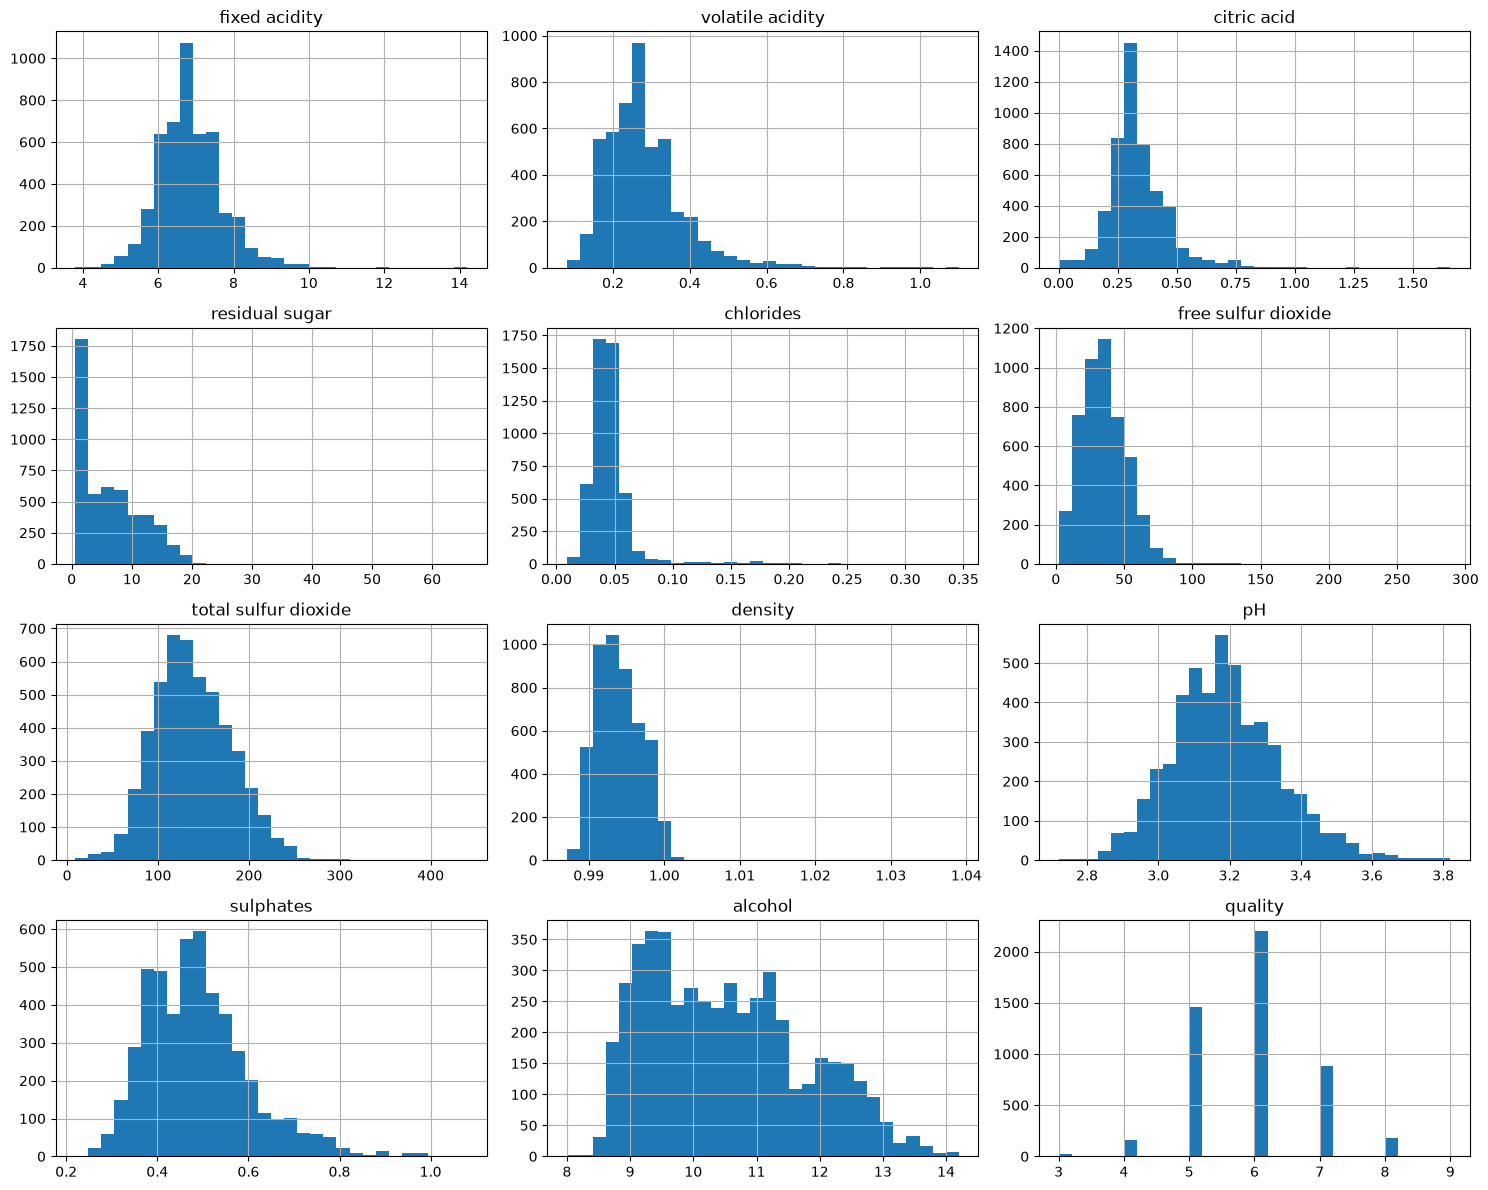

In [5]:
import matplotlib.pyplot as plt
df.hist(bins=30, figsize=(15, 12))
plt.tight_layout()
plt.show()

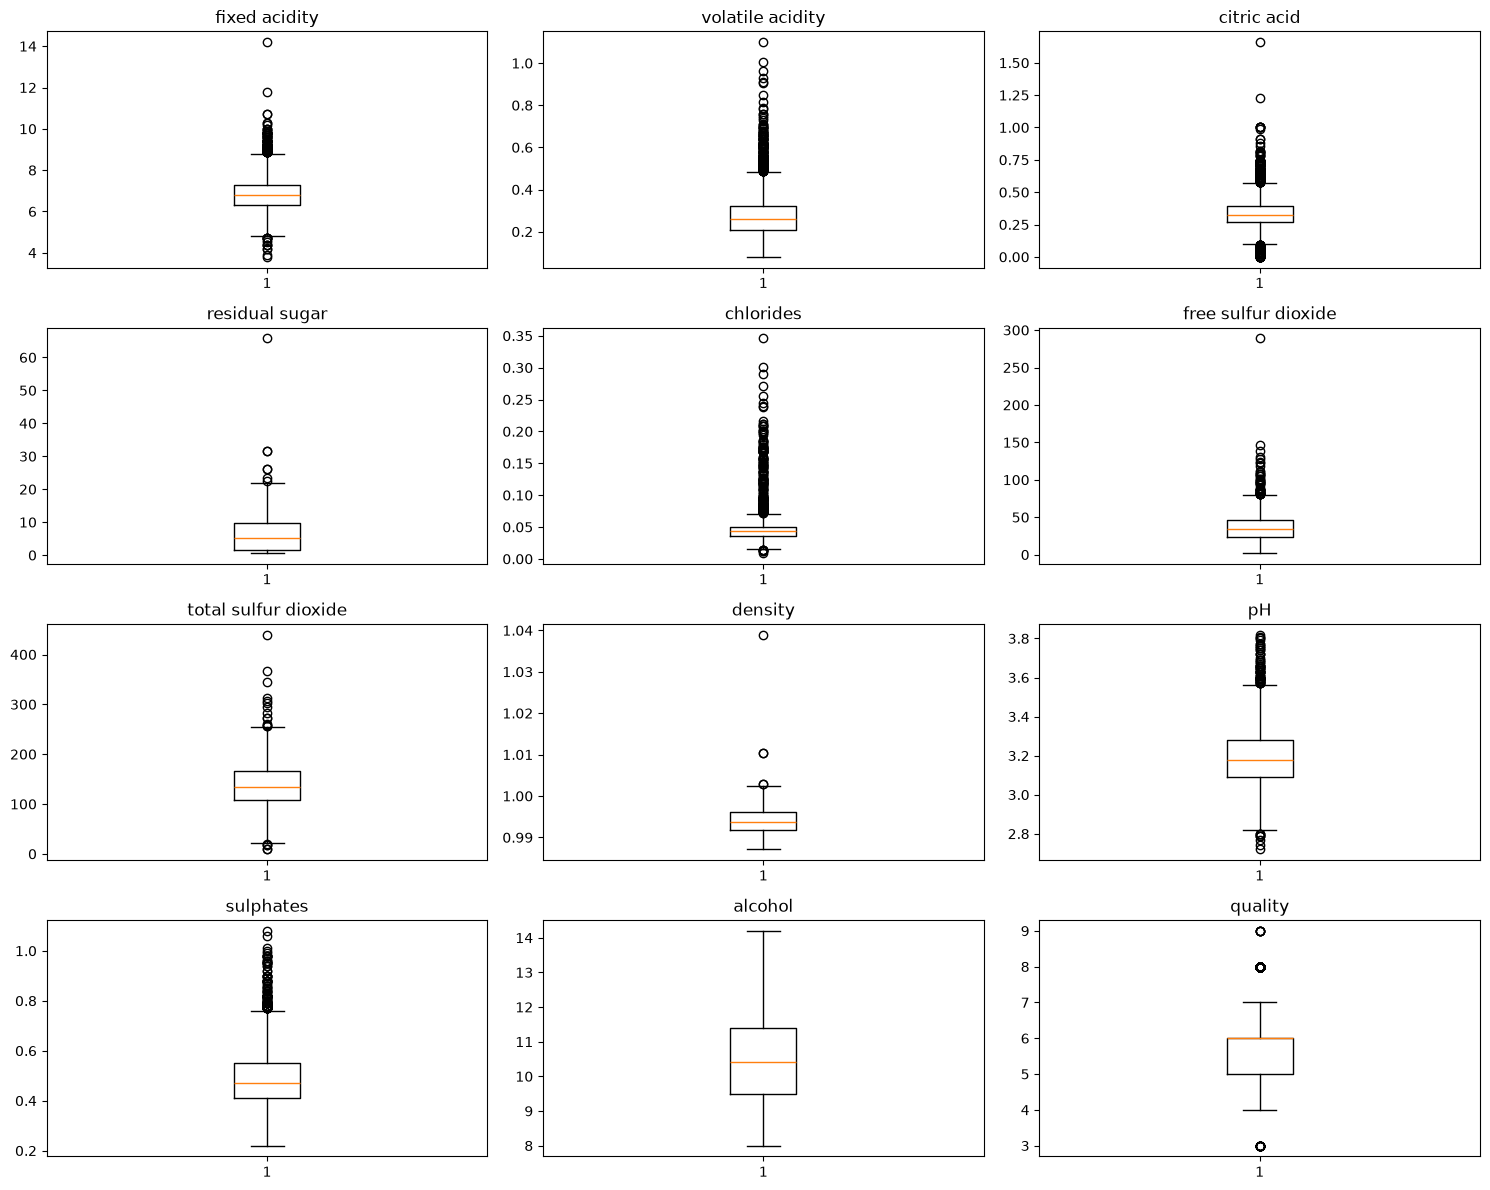

In [9]:
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
for column, ax in zip(df.columns, axes.flat):
    ax.boxplot(df[column])
    ax.set_title(column)
plt.tight_layout()
plt.show()

### intial EDA findings 
the dataset contains 4898 samples and 12 numerical columns with no missing values we found 937 duplicate rows which are currently retained because identical measurements do not necessarily indicate data entry errors
several features are right skewed especialy chlorides, chlorides also has high exass kurtosis indicating promient extreme values the ph distribution is more symmetric but this alone does not establish normality
the boxplots flag potential outliers in several features these values are retained for further investigation because unusual observations may samples rather than errors

In [11]:
shape_state = pd.DataFrame({"skewness": df.skew(),
"excess_kurtosis":df.kurt()})

display(shape_state.round(2))

,skewness,excess_kurtosis
fixed acidity,0.65,2.17
volatile acidity,1.58,5.09
citric acid,1.28,6.17
residual sugar,1.08,3.47
chlorides,5.02,37.56
free sulfur dioxide,1.41,11.47
total sulfur dioxide,0.39,0.57
density,0.98,9.79
pH,0.46,0.53
sulphates,0.98,1.59


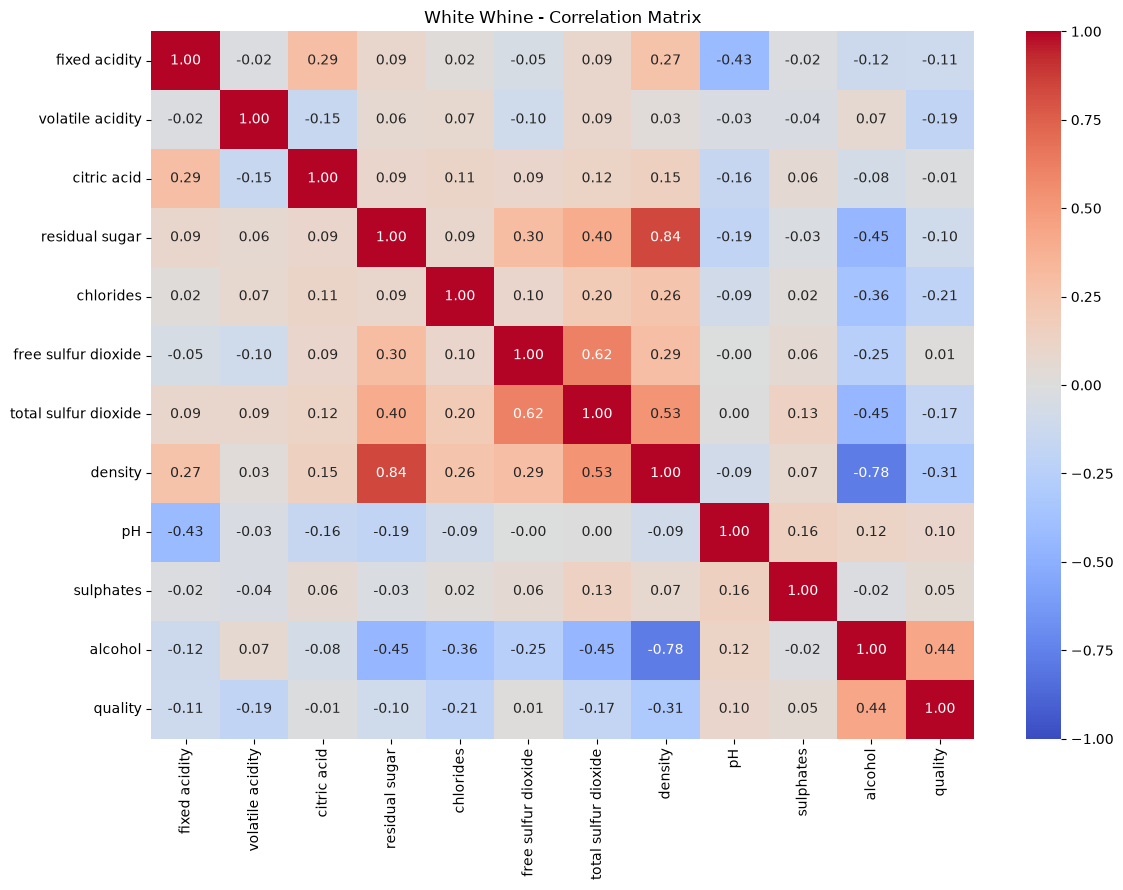

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(),
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            vmin=-1,
            vmax=1,
            center = 0)
plt.title("White Whine - Correlation Matrix")
plt.tight_layout()
plt.show()           

In [16]:
%pip install seaborn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### eda conclusions 
density correlates positively with sugar(0.84) and negatively with alcohol(-0.78)
suggesting overlapping information chlorides show strong right skewness and heavy tails. extreme values may reflect geniune variation, noise or measurement/data entry errors.
since errors cannot be confirmed we retain them for further analysis.

In [19]:
from sklearn.preprocessing import StandardScaler
X = df.drop(columns=["quality"])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled.shape)

(4898, 11)


In [23]:
from sklearn.decomposition import PCA
import pandas as pd 
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
pca_summery = pd.DataFrame({"Explained Variance (%)": pca.explained_variance_ratio_*100,
"cumulative variance (%)": pca.explained_variance_ratio_.cumsum()*100
},
index = [f"pc{i+1}" for i in range(X.shape[1])])
display(pca_summery.round(2))

,Explained Variance (%),cumulative variance (%)
pc1,29.29,29.29
pc2,14.32,43.61
pc3,11.11,54.72
pc4,9.26,63.98
pc5,8.85,72.83
pc6,8.53,81.36
pc7,6.61,87.97
pc8,5.45,93.42
pc9,3.76,97.18
pc10,2.63,99.81


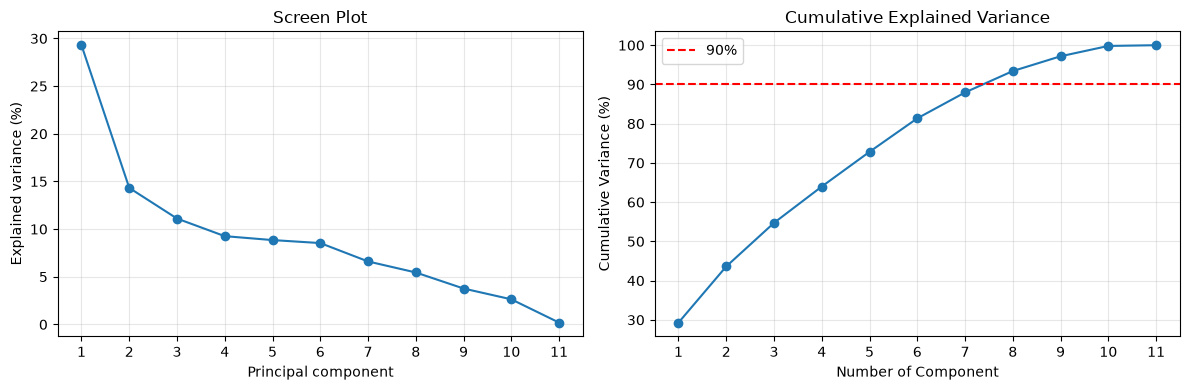

In [26]:
import matplotlib.pyplot as plt
components = range(1, len(pca.explained_variance_ratio_)+1)
variance = pca.explained_variance_ratio_*100
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(components, variance, marker="o")
axes[0].set_title("Screen Plot")
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Explained variance (%)")

axes[1].plot(components, variance.cumsum(), marker="o")
axes[1].axhline(90,color = "red", linestyle = "--", label="90%")
axes[1].set_title("Cumulative Explained Variance")
axes[1].set_xlabel("Number of Component")
axes[1].set_ylabel("Cumulative Variance (%)")
axes[1].legend()
for ax in axes:
    ax.set_xticks(list(components))
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


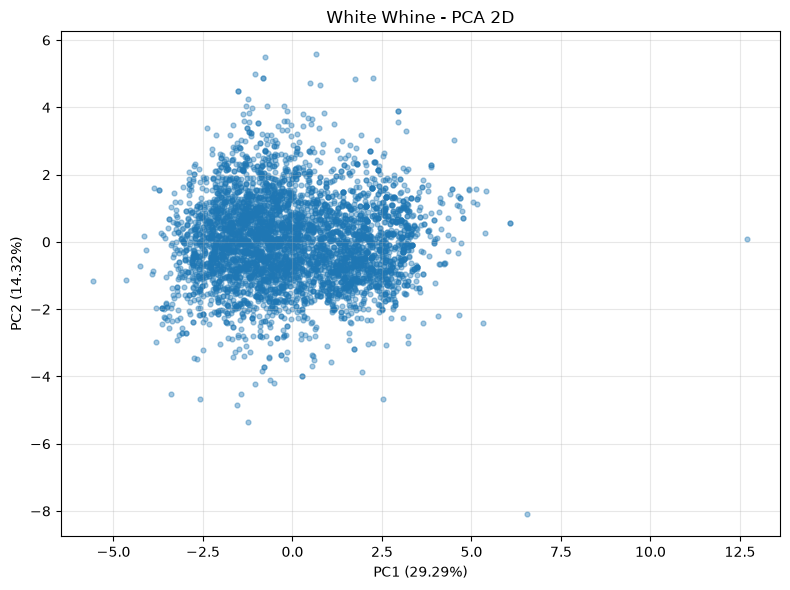

In [27]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    s=12,
    alpha = 0.4
)
plt.xlabel("PC1 (29.29%)")
plt.ylabel("PC2 (14.32%)")
plt.title("White Whine - PCA 2D")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

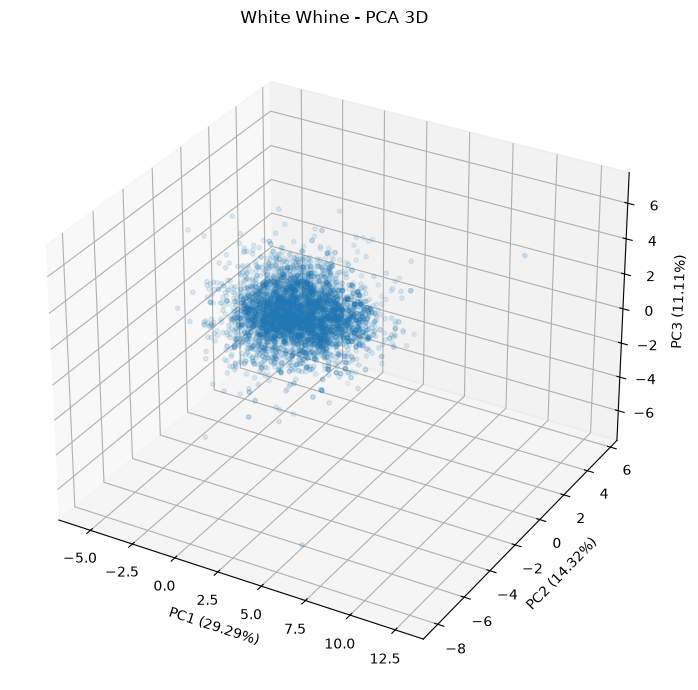

In [30]:
fig = plt.figure(figsize = (9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2],
    s=10,
    alpha = 0.4
)
ax.set_xlabel("PC1 (29.29%)")
ax.set_ylabel("PC2 (14.32%)")
ax.set_zlabel("PC3 (11.11%)")
ax.set_title("White Whine - PCA 3D")
plt.tight_layout()
plt.show()



In [31]:
component_weights = pd.DataFrame(
    pca.components_[:3].T,
    index=X.columns,
    columns=["PC1", "PC2", "PC3"]
)
display(component_weights.round(3))

,PC1,PC2,PC3
fixed acidity,0.157,0.588,-0.121
volatile acidity,0.005,-0.052,0.591
citric acid,0.144,0.345,-0.504
residual sugar,0.427,-0.009,0.214
chlorides,0.212,0.009,0.102
free sulfur dioxide,0.300,-0.290,-0.279
total sulfur dioxide,0.407,-0.244,-0.124
density,0.512,-0.006,0.129
pH,-0.129,-0.581,-0.127
sulphates,0.043,-0.223,-0.433


### pca interpretation
pc1 mainaly contrasts density residual sugar and total sulfur dioxide with alcoholn
pc2 primarly reflects acidity with opporsite weights for fixed acidty.and ph
pc3 constract volatile acidity with citric acid and sulphates
eight components retain 93.4% of thge variance 
the 2D and 3D projections retain only 43.6% anf 54.7%
respectively and show no clearly  seperated clusters in displayed views

In [ ]:
### 4 clustering

In [33]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
results = []
for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(
        X_scaled, labels,
        sample_size = 2000,
        random_state = 42
    )
    results.append({"k": k, "Silhouette": score})
kmeans_results = pd.DataFrame(results)
display(kmeans_results.round(3))

,k,Silhouette
0,2,0.211
1,3,0.140
2,4,0.157
3,5,0.141
4,6,0.144
5,7,0.122
6,8,0.122


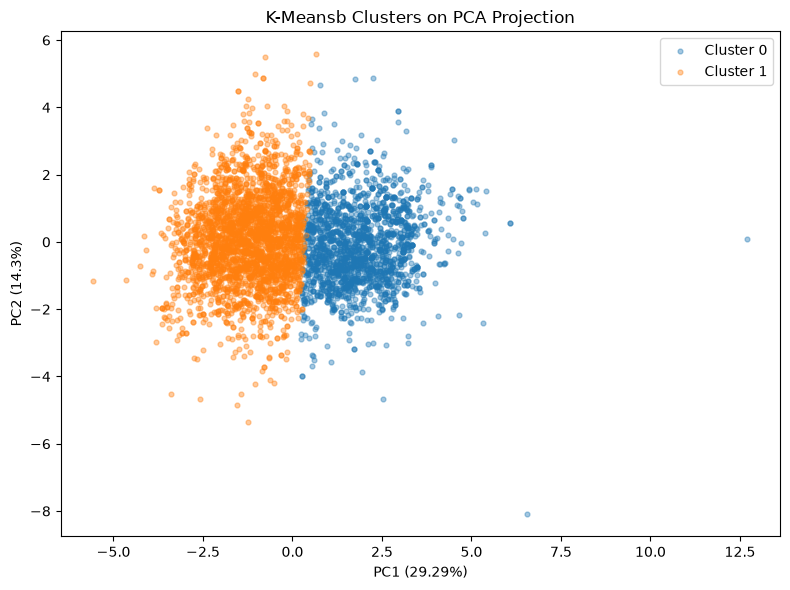

In [35]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
plt.figure(figsize=(8, 6))
for cluster in range(2):
    mask = kmeans_labels ==cluster
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=12,
        alpha=0.4,
        label=f"Cluster {cluster}"
    )
plt.xlabel("PC1 (29.29%)")
plt.ylabel("PC2 (14.3%)")
plt.title("K-Meansb Clusters on PCA Projection")
plt.legend()
plt.tight_layout()
plt.show()

In [38]:
cluster_data = X.copy()
cluster_data["Cluster"] = kmeans_labels
print("Samples in each cluster:")
display(cluster_data.groupby("Cluster").size())
print("Mean measurements in each cluster:")
display(cluster_data.groupby("Cluster").mean().T.round(3))

Samples in each cluster:


Cluster
0    1957
1    2941
dtype: int64

Mean measurements in each cluster:


Cluster,0,1
fixed acidity,7.003,6.756
volatile acidity,0.283,0.275
citric acid,0.363,0.315
residual sugar,10.692,3.530
chlorides,0.054,0.040
free sulfur dioxide,45.465,28.549
total sulfur dioxide,170.898,116.710
density,0.997,0.992
pH,3.158,3.209
sulphates,0.497,0.485


### k-means interpretation 
among k=2-8 k=2 achieved the highest sampled
silhouette score (0.211) indicating weak separation
cluster 0 has higher mean residual sugar density and sulfur dioxide but lower alcohol than cluster 1
these groups describe different chemical profiles not necessarily distinct natural wine categories

In [41]:
scaled_clusters = pd.DataFrame(X_scaled, columns=X.columns)
global_variance = scaled_clusters.var(ddof=0).mean()
cluster_variance = (
    scaled_clusters.groupby(kmeans_labels)
    .var(ddof=0)
    .mean(axis=1)
)
variance_comparison = pd.DataFrame({
    "Mean cluster variance": cluster_variance,
    "Global mean variance": global_variance,
    "Ratio": cluster_variance / global_variance
})
display(variance_comparison.round(3))

,Mean cluster variance,Global mean variance,Ratio
0,0.889,1.0,0.889
1,0.724,1.0,0.724


In [ ]:
## mean within cluster variance is 0.889 for ckuster 0 and 0.724 for cluster 1 compared witha global variance of 1 after standardization
cluster 1 is more compact by this measurement
lower variance alone does not imply well seperated clusters

In [42]:
from sklearn.cluster import DBSCAN 
dbscan_results =[]
for eps in [0.5, 1.0, 1.5, 2.0]:
    model = DBSCAN(eps=eps, min_samples=10)
    labels = model.fit_predict(X_scaled)
    n_clusters = len(set(labels) - {-1})
    noise_percent = (labels == -1).mean() * 100
    dbscan_results.append({
        "eps": eps,
        "Clusters": n_clusters,
        "Noise (%)": noise_percent
    })
display(pd.DataFrame(dbscan_results).round(2))

,eps,Clusters,Noise (%)
0,0.5,0,100.00
1,1.0,20,89.61
2,1.5,2,27.13
3,2.0,3,7.08


In [45]:
for eps in [1.5, 2.0]:
    model = DBSCAN(eps=eps, min_samples=10)
    labels = model.fit_predict(X_scaled)

    print(f"eps ={eps}")
    display(pd.Series(labels).value_counts().sort_index())
    

eps =1.5


-1    1329
 0    3559
 1      10
Name: count, dtype: int64

eps =2.0


-1     347
 0    4515
 1      22
 2      14
Name: count, dtype: int64

In [47]:
from sklearn.cluster import AgglomerativeClustering
hierarchical = AgglomerativeClustering(
    n_clusters=2, linkage="ward"
)
hier_labels = hierarchical.fit_predict(X_scaled)
display(pd.Series(hier_labels).value_counts().sort_index())
score = silhouette_score(
    X_scaled, hier_labels,
    sample_size=2000, random_state=42
)
print("silhouette:", round(score, 3))

0    1965
1    2933
Name: count, dtype: int64

silhouette: 0.177


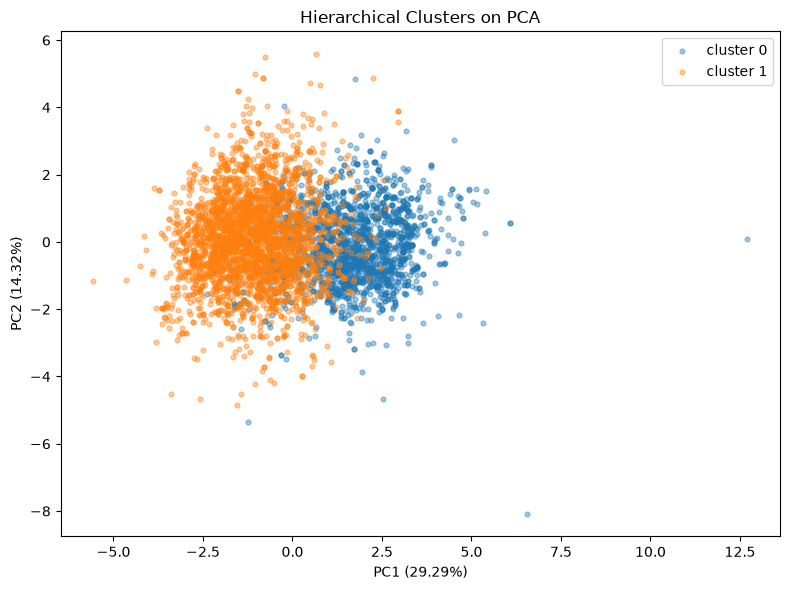

In [50]:
plt.figure(figsize=(8, 6))
for cluster in range(2):
    mask = hier_labels == cluster 
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        s=12, alpha=0.4, label=f"cluster {cluster}"
    )
plt.xlabel("PC1 (29.29%)")
plt.ylabel("PC2 (14.32%)")
plt.title("Hierarchical Clusters on PCA")
plt.legend()
plt.tight_layout()
plt.show()

In [51]:
print("Mean feature values:")
display(X.groupby(hier_labels).mean().T.round(3))
print("Mean within-cluster variance:")
display(
    scaled_clusters.groupby(hier_labels)
    .var(ddof=0).mean(axis=1).round(3)
)

Mean feature values:


,0,1
fixed acidity,6.921,6.810
volatile acidity,0.271,0.283
citric acid,0.365,0.313
residual sugar,10.628,3.553
chlorides,0.053,0.041
free sulfur dioxide,45.597,28.415
total sulfur dioxide,166.522,119.494
density,0.997,0.992
pH,3.157,3.209
sulphates,0.492,0.488


Mean within-cluster variance:


0    0.913
1    0.768
dtype: float64

## ward hierarchical clustering produced chemical profiels similiar to k-means
cluster 0 has higher mean sugar density and sulfur dioxide but lowe akcohol

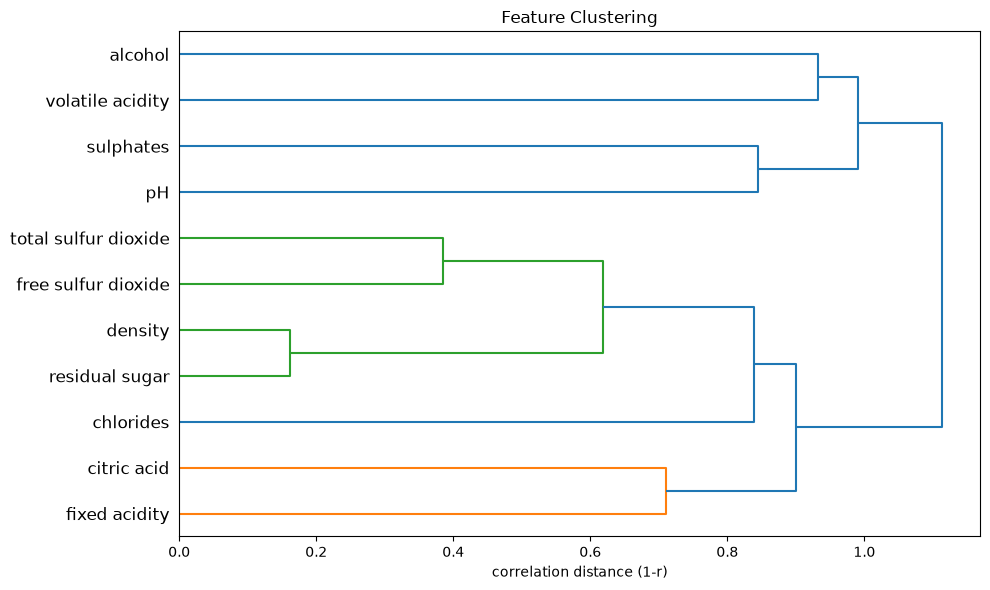

In [58]:
from scipy.cluster.hierarchy import linkage, dendrogram
feature_linkage=linkage(
    X_scaled.T,
    method="average",
    metric="correlation"
)
plt.figure(figsize=(10, 6))
dendrogram(
    feature_linkage,
    labels=X.columns,
    orientation="right"
)
plt.title("Feature Clustering")
plt.xlabel("correlation distance (1-r)")
plt.tight_layout()
plt.show()

### feature clustering - conclusions
residual sugar and density form closest pair, followed by free and total sulfur. these relationships suggest partially redundant information. alcohol  joins other features at a relatively large distance, indicating weaker positive similarity under the chosen distance measure
unlike sample clustering which groups wines, feature clustering groups related measurements it organized relationships from the correlation matrix into a hierarchy and may guide feature selections
this is useful in domaines with many relatedmeasurements such aschemistry and sensor data.

###5.1 z- score

In [60]:
from scipy.stats import zscore
import numpy as np
z_score = np.abs(zscore(X, axis=0))
z_anomalies = (z_score > 3).any(axis=1)
print("Anomalies:", z_anomalies.sum())
print(f"percentage: {z_anomalies.mean()*100:.2f}%")

Anomalies: 396
percentage: 8.08%


### conclusion
z - score flagged 396 wines (8.08%) with |z| > 3 in at least one feature.
skewed distributions and testing many features may increase false alarm 
the method ignored correlations and may miss unusual feature combinations.

In [63]:
from sklearn.ensemble import IsolationForest
from time import perf_counter
iso = IsolationForest(contamination=0.05, random_state=42)
start = perf_counter()
iso_anomalies = iso.fit_predict(X) == -1
iso_runtime = perf_counter() - start
iso_scores = -iso.score_samples(X)
print("Anomalies:", iso_anomalies.sum())
print(f"Percentage: {iso_anomalies.mean()*100:.2f}%")
print(f"Runtime: {iso_runtime:.3f} seconds")

Anomalies: 245
Percentage: 5.00%
Runtime: 1.276 seconds


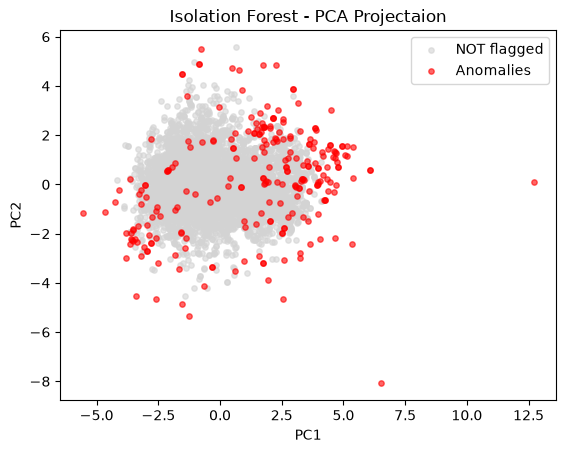

In [64]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
pca_view = PCA(n_components=2).fit_transform(
    StandardScaler().fit_transform(X)
)
for mask, color, label in[
    (~iso_anomalies, "lightgray", "NOT flagged"),
    (iso_anomalies, "red", "Anomalies")
]:
    plt.scatter(
        pca_view[mask,0], pca_view[mask, 1],
        c=color, label=label, s=15, alpha=0.6
    )
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Isolation Forest - PCA Projectaion")
plt.legend()
plt.show()

In [66]:
for contamination in [0.01, 0.05, 0.10]:
    threshold = np.quantile(iso_scores, 1 - contamination)
    flagged = iso_scores > threshold
    print(f"{contamination:.0%}: {flagged.sum()} anomalies")

1%: 49 anomalies
5%: 245 anomalies
10%: 490 anomalies


Isolation forest flags easily isolated sapels: hiher scores indicate greater abnormality. as 5% contamintaion 245 wines are flagged
1% and 10% flagged 49 and 490
 it needs no gussian 

In [68]:
from sklearn.neighbors import LocalOutlierFactor
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_labels = lof.fit_predict(X_scaled)

lof_anomalies = lof_labels == -1
lof_scores = -lof.negative_outlier_factor_
print("LOF anomalies:", lof_anomalies.sum())

LOF anomalies: 245


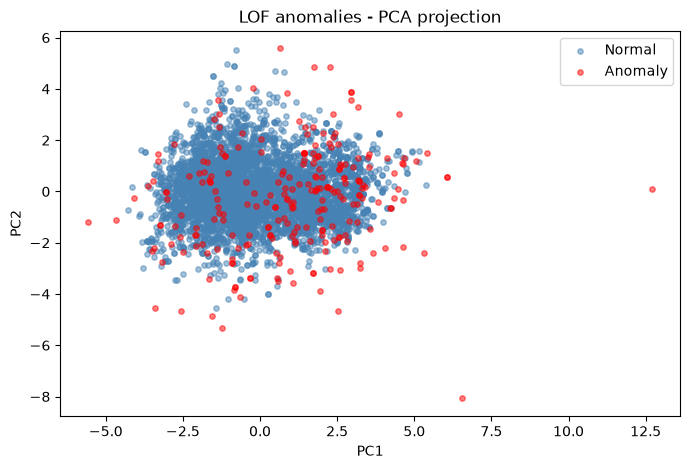

In [72]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
lof_pca =PCA(n_components=2).fit_transform(X_scaled)
plt.figure(figsize=(8, 5))
for mask, color, label in[
    (~lof_anomalies, "steelblue", "Normal"),
    (lof_anomalies, "red", "Anomaly")
]:
    plt.scatter(
        lof_pca[mask, 0], lof_pca[mask, 1],
        c=color, label=label, s=15, alpha=0.5
    )
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("LOF anomalies - PCA projection")
plt.legend()
plt.show()

In [75]:
for k in [10, 20, 50]:
    model = LocalOutlierFactor(
        n_neighbors=k, contamination=0.05
    )
    flags = model.fit_predict(X_scaled) == -1
    overlap = (flags & lof_anomalies).sum()
    print(
        f"k={k}: {flags.sum()} anomalies, "
        f"{overlap} shared with k=20"
    )


k=10: 245 anomalies, 186 shared with k=20
k=20: 245 anomalies, 245 shared with k=20
k=50: 244 anomalies, 175 shared with k=20


### 6 comparison of anomaly detection methods

In [80]:
iso_anomalies = iso_scores > np.quantile(iso_scores, 0.95)
shared = (iso_anomalies & lof_anomalies).sum()
only_iso = (iso_anomalies & ~lof_anomalies).sum()
only_lof = (lof_anomalies & ~iso_anomalies).sum()
print("Shared anomalies:", shared)
print("Only Isolation Forest:", only_iso)
print("Only LOF:", only_lof)

Shared anomalies: 101
Only Isolation Forest: 144
Only LOF: 144


In [85]:
import pandas as pd
comparison = pd.DataFrame({
    "Z-score": np.asarray(z_anomalies),
    "Isolatin Forest": np.asarray(iso_anomalies),
    "LOF": np.asarray(lof_anomalies)
})
print("Anomalies per method:")
print(comparison.sum())
print("\nShared anomalies between methods:")
display(comparison.astype(int).T @ comparison.astype(int))
print("\nShared by all three:", comparison.all(axis=1).sum())
print("\nDetected by only method:")
print(comparison[comparison.sum(axis=1) == 1].sum())

Anomalies per method:
Z-score            396
Isolatin Forest    245
LOF                245
dtype: int64

Shared anomalies between methods:


,Z-score,Isolatin Forest,LOF
Z-score,396,154,112
Isolatin Forest,154,245,101
LOF,112,101,245



Shared by all three: 77

Detected by only method:
Z-score            207
Isolatin Forest     67
LOF                109
dtype: int64


### 6 method comparison
- agreement: all three methods identified 77 shared anomalies z score alone idetnitified 207 samples, iisolation forest alone identified 67 and lof alone 109.
their different definitions of an anamoly explain this partial agreement.
- scaling: z score standardizes each feature
lof. requires scaling because it uses distance isolatin forest is less sensetive to feture scales.
-dimensionality: with more features z score has more opportunities to flag extreme values while lofs distance may become less informative. isolation forest
can handle many feturea but irrelevant features can weaken detection.
-runtime: z score is generally the fastest
isolation forest scakes well while lofs neighbor searches can become expensive on large datasets
- interpretability: z score is easiest to explain throuh individual extreme features lof comparse a sample with neighbors isolation forests combained tree results are less 
straightoward to interpret.
- nouse : z scores mean and standart devition can distroied by extreme values 
- errors: a false positive could flag a legimate wine with unusual chemical prpreties
leading to unnecessary testing or rejection

## 7 critical analysis nand reflection
anaomaly detection is difficult because there is no sungle definition of "abnormal". without verified anomaly labels 
disagreement between methods does not tell us wich method is correct.
- dimensionality
as the number of features increase data become sparse and distance can become more similiar. this makes neighboods less informative and can weaken distance basd
method such as lof.
irrelavent features can also hide meaningful difference
- noise versus geniune anomalies: noise may result from measurment nor data entry errors, while a geniune anomaly is unusual but real observation.
for exampel a wine with unusually high residual sugar could be a legitimate sweet wine rather than an error.
- gussian assumptions: z score can be calculated without normally distributed data but interpreting large scores are rare events relies on disributional asuumptions
in skewed or havy tailed features valid wines may be flagged unnecessary.
-PCA limitation: a 2d PCA plot retains only part of the information. an anomaly in discarded component may appear normal and groups that overlap in the pilot 
may be spared in the original space.
ethical considerations
-false alarm: repated false alarm wasts rescurce and reduce trust.
-surveillance: detection may help identify threats  but it can also invade privacy and unfairly flag uncommon yet legitimate behavor
-medicine - na false positive may cause axiety and unnesessary tests
-cybercurity - missing an attack can wxpose sensetive data
f
for thw wine dataset anomaly flags should guide further indpection rather  than automatically justify removing samples or declaring wines defective